In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from datetime import datetime
from scipy.stats import chi2_contingency
from scipy.stats import kruskal

In [2]:
df = pd.read_excel('data/working_dataset.xlsx')

### Target variable

In [3]:
# Créer le taux d'impayé
df["TAUX_IMPAYE"] = df["NBIMP"] / df["NB_ECH"]

# Créer les niveaux de risque
def niveau_risque(x):
    if x <= 0.02:
        return "Faible"
    elif x <= 0.25:
        return "Moyen"
    else:
        return "Élevé"

df["NIVEAU_RISQUE"] = df["TAUX_IMPAYE"].apply(niveau_risque)

In [4]:
df['NIVEAU_RISQUE'].value_counts(normalize=True).mul(100).round(2)

NIVEAU_RISQUE
Faible    45.08
Moyen     27.51
Élevé     27.40
Name: proportion, dtype: float64

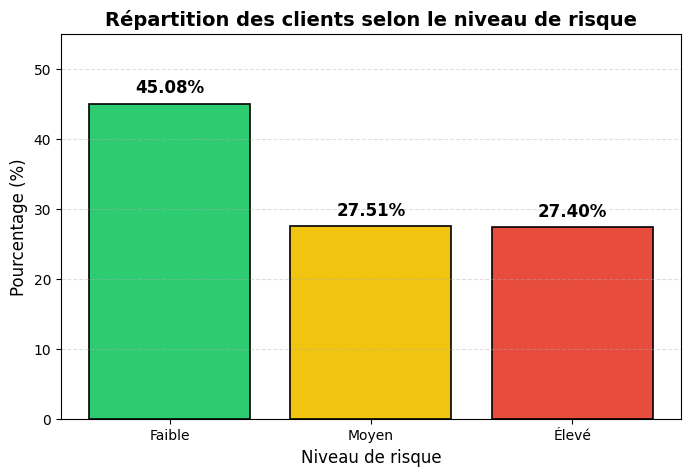

In [5]:
# Calculer les pourcentages
data = df["NIVEAU_RISQUE"].value_counts(normalize=True).mul(100).round(2)

# Garder l'ordre logique
ordre = ["Faible", "Moyen", "Élevé"]
data = data.reindex(ordre)

# Couleurs
colors = ["#2ecc71", "#f1c40f", "#e74c3c"]

# Graphique
plt.figure(figsize=(8, 5))
bars = plt.bar(data.index, data.values, color=colors, edgecolor="black", linewidth=1.2)

# Ajouter les pourcentages au-dessus des barres
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.2f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

# Mise en forme
plt.title("Répartition des clients selon le niveau de risque", fontsize=14, fontweight="bold")
plt.xlabel("Niveau de risque", fontsize=12)
plt.ylabel("Pourcentage (%)", fontsize=12)
plt.ylim(0, data.max() + 10)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

# Analyse Bivarié

## Variables Qualitatives

### NIVEAU_RISQUE x INDLIB_GROUPE

In [6]:
# Tableau croisé en pourcentage
tableau = pd.crosstab(
    df["INDLIB_GROUPE"],
    df["NIVEAU_RISQUE"],
    normalize="index"
).mul(100).round(2)

# Réorganiser les colonnes
ordre = ["Faible", "Moyen", "Élevé"]
tableau = tableau[ordre]

# Afficher le tableau
display(tableau)

NIVEAU_RISQUE,Faible,Moyen,Élevé
INDLIB_GROUPE,,,
Agriculture/Élevage,52.00,24.00,24.00
Autres,36.36,54.55,9.09
BTP/Construction,65.38,19.23,15.38
Commerce,42.35,28.38,29.26
Eau/Électricité,0.00,0.00,100.00
Industrie,58.14,16.28,25.58
Services,54.00,24.00,22.00
Transport,37.50,25.00,37.50


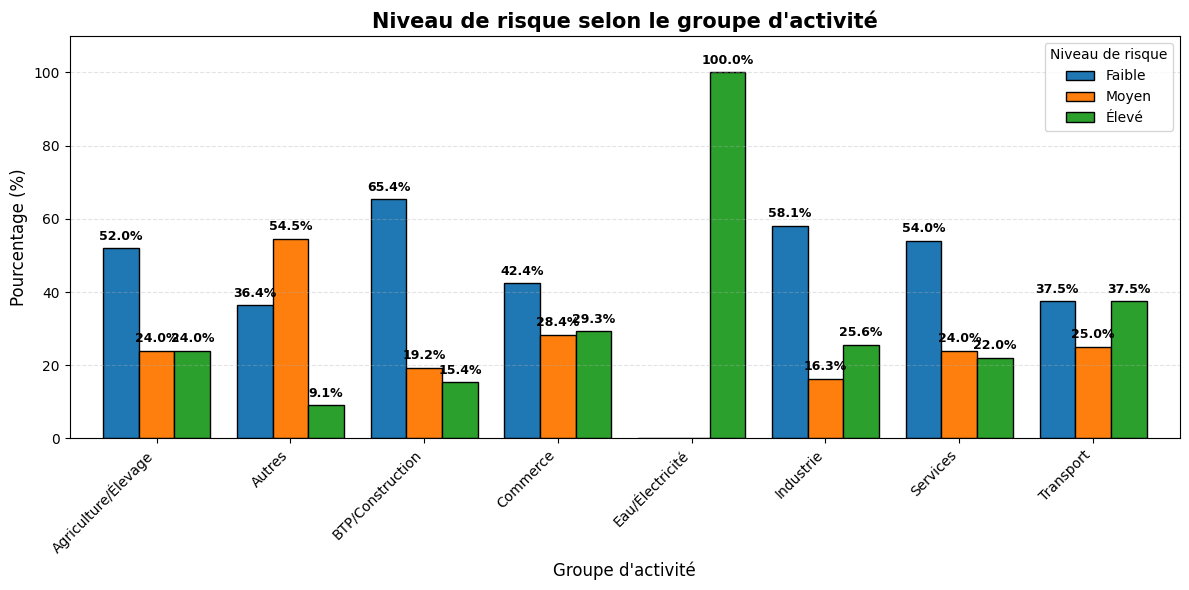

In [7]:
# Ordre des colonnes
ordre = ["Faible", "Moyen", "Élevé"]

# Recréer le tableau en POURCENTAGE
tableau_indlib = pd.crosstab(
    df["INDLIB_GROUPE"],
    df["NIVEAU_RISQUE"],
    normalize="index"
).mul(100).round(2)

tableau_indlib = tableau_indlib[ordre]

# Graphique
ax = tableau_indlib.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8,
    edgecolor="black"
)

plt.title(
    "Niveau de risque selon le groupe d'activité",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Groupe d'activité", fontsize=12)
plt.ylabel("Pourcentage (%)", fontsize=12)

plt.xticks(rotation=45, ha="right")
plt.legend(title="Niveau de risque")
plt.grid(axis="y", linestyle="--", alpha=0.35)

# Ajouter les pourcentages sur les barres
for container in ax.containers:
    labels = [
        f"{value:.1f}%" if value > 0 else ""
        for value in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        fontsize=9,
        fontweight="bold",
        padding=4
    )

plt.ylim(0, 110)

plt.tight_layout()
plt.show()

In [10]:
# Tableau croisé en effectifs
tableau = pd.crosstab(df["INDLIB_GROUPE"], df["NIVEAU_RISQUE"])

# Test du Khi-deux
chi2, p_value, dof, expected = chi2_contingency(tableau)

print("Statistique Khi-deux :", chi2)
print("p-value :", p_value)
print("Degrés de liberté :", dof)

if p_value < 0.05:
    print("Il existe une relation statistiquement significative entre le groupe d'activité et le niveau de risque.")
else:
    print("Il n'existe pas de relation statistiquement significative entre le groupe d'activité et le niveau de risque.")

Statistique Khi-deux : 25.951129405641968
p-value : 0.02625962938625251
Degrés de liberté : 14
Il existe une relation statistiquement significative entre le groupe d'activité et le niveau de risque.


In [11]:
pd.crosstab(df["INDLIB_GROUPE"], df["NIVEAU_RISQUE"], margins=True)

NIVEAU_RISQUE,Faible,Moyen,Élevé,All
INDLIB_GROUPE,,,,
Agriculture/Élevage,13,6,6,25
Autres,8,12,2,22
BTP/Construction,17,5,4,26
Commerce,288,193,199,680
Eau/Électricité,0,0,1,1
Industrie,25,7,11,43
Services,54,24,22,100
Transport,3,2,3,8
All,408,249,248,905


### NIVEAU_RISQUE x PORTEF

In [12]:
ordre = ["Faible", "Moyen", "Élevé"]

tableau_portef = pd.crosstab(
    df["PORTEF"],
    df["NIVEAU_RISQUE"],
    normalize="index"
).mul(100).round(2)

tableau_portef = tableau_portef[ordre]

display(tableau_portef)

NIVEAU_RISQUE,Faible,Moyen,Élevé
PORTEF,,,
DD,49.38,28.81,21.81
DDC,43.50,27.04,29.46


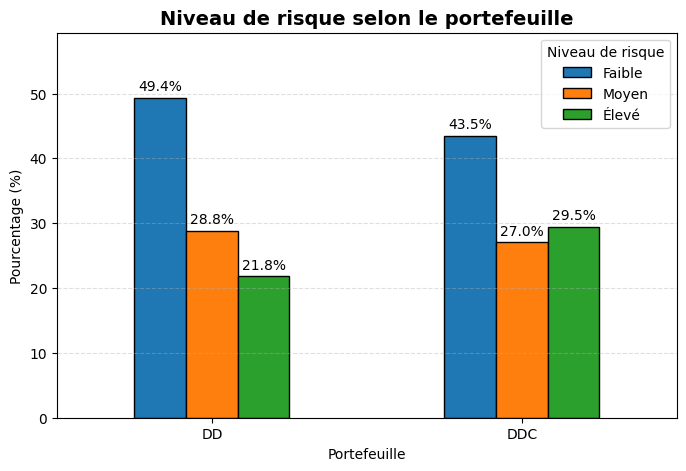

In [13]:
import matplotlib.pyplot as plt

ax = tableau_portef.plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="black"
)

plt.title("Niveau de risque selon le portefeuille", fontsize=14, fontweight="bold")
plt.xlabel("Portefeuille")
plt.ylabel("Pourcentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Niveau de risque")
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Ajouter les pourcentages sur les barres
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v:.1f}%" for v in container.datavalues],
        fontsize=10,
        padding=3
    )

plt.ylim(0, tableau_portef.values.max() + 10)

plt.show()

In [14]:
# Tableau croisé en effectifs
tableau_effectifs_portef = pd.crosstab(df["PORTEF"], df["NIVEAU_RISQUE"])

# Test du Khi-deux
chi2, p_value, dof, expected = chi2_contingency(tableau_effectifs_portef)

print("Statistique Khi-deux :", chi2)
print("p-value :", p_value)
print("Degrés de liberté :", dof)

if p_value < 0.05:
    print("Il existe une relation statistiquement significative entre la portefeuil et le niveau de risque.")
else:
    print("Il n'existe pas de relation statistiquement significative entre la portefeuil et le niveau de risque.")

Statistique Khi-deux : 5.355751225851782
p-value : 0.06870896365579678
Degrés de liberté : 2
Il n'existe pas de relation statistiquement significative entre la portefeuil et le niveau de risque.


### NIVEAU_RISQUE x PERIODE

In [15]:
# Ordre des niveaux de risque
ordre = ["Faible", "Moyen", "Élevé"]

# Tableau croisé en pourcentage
tableau_periode = pd.crosstab(
    df["PERIODE"],
    df["NIVEAU_RISQUE"],
    normalize="index"
).mul(100).round(2)

tableau_periode = tableau_periode[ordre]

display(tableau_periode)

NIVEAU_RISQUE,Faible,Moyen,Élevé
PERIODE,,,
A,100.00,0.00,0.00
B,42.37,40.68,16.95
M,43.66,26.74,29.61
S,0.00,0.00,100.00
T,50.83,26.52,22.65


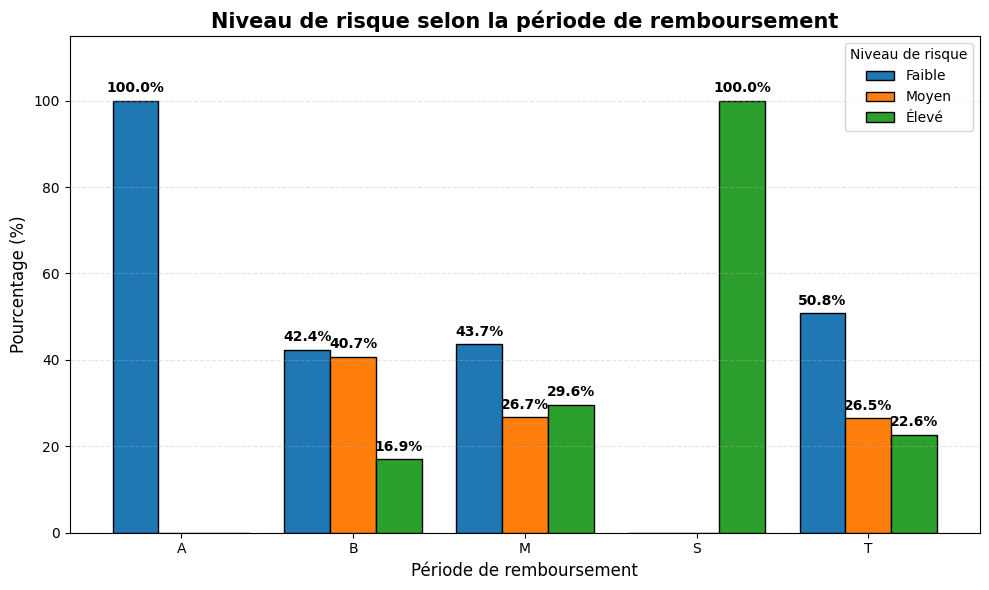

In [18]:
# Graphique
ax = tableau_periode.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.8,
    edgecolor="black"
)

plt.title("Niveau de risque selon la période de remboursement", fontsize=15, fontweight="bold")
plt.xlabel("Période de remboursement", fontsize=12)
plt.ylabel("Pourcentage (%)", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Niveau de risque")
plt.grid(axis="y", linestyle="--", alpha=0.35)

# Ajouter les pourcentages seulement si la valeur > 0
for container in ax.containers:
    labels = []
    for value in container.datavalues:
        if value > 0:
            labels.append(f"{value:.1f}%")
        else:
            labels.append("")
    
    ax.bar_label(
        container,
        labels=labels,
        fontsize=10,
        fontweight="bold",
        padding=4
    )

plt.ylim(0, tableau_periode.values.max() + 15)
plt.tight_layout()
plt.show()

In [17]:
# Tableau croisé en effectifs
tableau_effectifs_periode = pd.crosstab(df["PERIODE"], df["NIVEAU_RISQUE"])

display(tableau_effectifs_periode)

# Test du Khi-deux
chi2, p_value, dof, expected = chi2_contingency(tableau_effectifs_periode)

print("Statistique Khi-deux :", chi2)
print("p-value :", p_value)
print("Degrés de liberté :", dof)

if p_value < 0.05:
    print("Il existe une relation statistiquement significative entre la période et le niveau de risque.")
else:
    print("Il n'existe pas de relation statistiquement significative entre la période et le niveau de risque.")

NIVEAU_RISQUE,Faible,Moyen,Élevé
PERIODE,,,
A,2,0,0
B,25,24,10
M,289,177,196
S,0,0,1
T,92,48,41


Statistique Khi-deux : 15.750070760650814
p-value : 0.046100306829334595
Degrés de liberté : 8
Il existe une relation statistiquement significative entre la période et le niveau de risque.


### NIVEAU_RISQUE x SEX

In [19]:
ordre = ["Faible", "Moyen", "Élevé"]

# Tableau croisé en pourcentage
tableau_sex = pd.crosstab(
    df["SEX"],
    df["NIVEAU_RISQUE"],
    normalize="index"
).mul(100).round(2)

tableau_sex = tableau_sex[ordre]

display(tableau_sex)

NIVEAU_RISQUE,Faible,Moyen,Élevé
SEX,,,
Female,46.94,30.61,22.45
Male,44.57,26.66,28.77


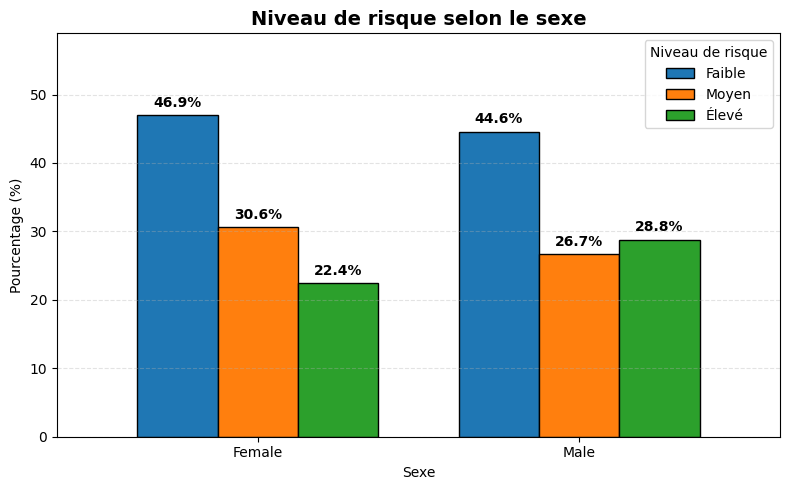

In [20]:
ax = tableau_sex.plot(
    kind="bar",
    figsize=(8, 5),
    width=0.75,
    edgecolor="black"
)

plt.title("Niveau de risque selon le sexe", fontsize=14, fontweight="bold")
plt.xlabel("Sexe")
plt.ylabel("Pourcentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Niveau de risque")
plt.grid(axis="y", linestyle="--", alpha=0.35)

# Ajouter les pourcentages, sans afficher les 0
for container in ax.containers:
    labels = [
        f"{value:.1f}%" if value > 0 else ""
        for value in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        fontsize=10,
        fontweight="bold",
        padding=4
    )

plt.ylim(0, tableau_sex.values.max() + 12)
plt.tight_layout()
plt.show()

In [21]:
# Tableau croisé en effectifs
tableau_effectifs_sex = pd.crosstab(df["SEX"], df["NIVEAU_RISQUE"])

display(tableau_effectifs_sex)

# Test du Khi-deux
chi2, p_value, dof, expected = chi2_contingency(tableau_effectifs_sex)

print("Statistique Khi-deux :", chi2)
print("p-value :", p_value)
print("Degrés de liberté :", dof)

if p_value < 0.05:
    print("Il existe une relation statistiquement significative entre le sexe et le niveau de risque.")
else:
    print("Il n'existe pas de relation statistiquement significative entre le sexe et le niveau de risque.")

NIVEAU_RISQUE,Faible,Moyen,Élevé
SEX,,,
Female,92,60,44
Male,316,189,204


Statistique Khi-deux : 3.305016083528908
p-value : 0.19156884294764298
Degrés de liberté : 2
Il n'existe pas de relation statistiquement significative entre le sexe et le niveau de risque.


### NIVEAU_RISQUE x ETATCIVIL

In [22]:
ordre = ["Faible", "Moyen", "Élevé"]

# Tableau croisé en pourcentage
tableau_etatcivil = pd.crosstab(
    df["ETATCIVIL"],
    df["NIVEAU_RISQUE"],
    normalize="index"
).mul(100).round(2)

tableau_etatcivil = tableau_etatcivil[ordre]

display(tableau_etatcivil)

NIVEAU_RISQUE,Faible,Moyen,Élevé
ETATCIVIL,,,
Married,55.39,18.96,25.65
Single,40.72,31.13,28.14


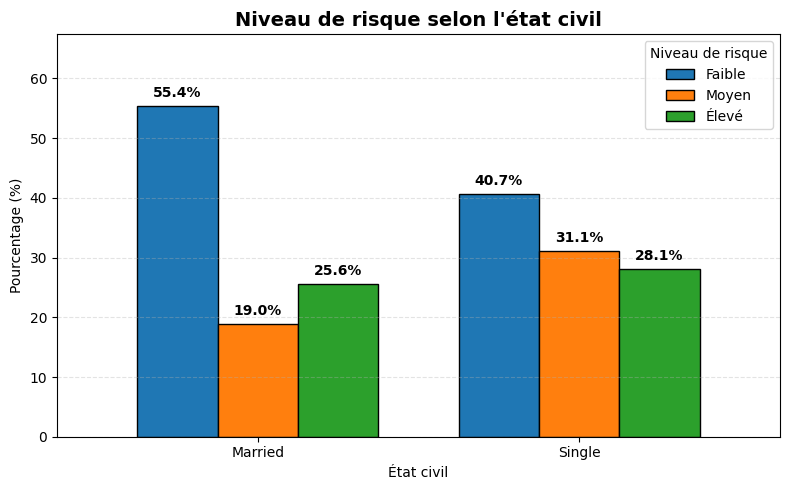

In [23]:
ax = tableau_etatcivil.plot(
    kind="bar",
    figsize=(8, 5),
    width=0.75,
    edgecolor="black"
)

plt.title("Niveau de risque selon l'état civil", fontsize=14, fontweight="bold")
plt.xlabel("État civil")
plt.ylabel("Pourcentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Niveau de risque")
plt.grid(axis="y", linestyle="--", alpha=0.35)

# Ajouter les pourcentages, sans afficher les 0
for container in ax.containers:
    labels = [
        f"{value:.1f}%" if value > 0 else ""
        for value in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        fontsize=10,
        fontweight="bold",
        padding=4
    )

plt.ylim(0, tableau_etatcivil.values.max() + 12)
plt.tight_layout()
plt.show()

In [38]:
# Tableau croisé en effectifs
tableau_effectifs_sect = pd.crosstab(
    df["ETATCIVIL"],
    df["NIVEAU_RISQUE"]
)

display(tableau_effectifs_sect)

# Test du Khi-deux
chi2, p_value, dof, expected = chi2_contingency(tableau_effectifs_sect)

print("Statistique Khi-deux :", chi2)
print("p-value :", p_value)
print("Degrés de liberté :", dof)

if p_value < 0.05:
    print("Il existe une relation statistiquement significative entre l'état civil et le niveau de risque.")
else:
    print("Il n'existe pas de relation statistiquement significative entre l'état civil et le niveau de risque.")

NIVEAU_RISQUE,Faible,Moyen,Élevé
ETATCIVIL,,,
Married,149,51,69
Single,259,198,179


Statistique Khi-deux : 19.6310234766237
p-value : 5.4598085588388266e-05
Degrés de liberté : 2
Il existe une relation statistiquement significative entre l'état civil et le niveau de risque.


### NIVEAU_RISQUE x WILAYA_NAISSANCE

In [24]:
df['WILAYA_NAISSANCE'].value_counts(normalize=True).mul(100).round(2)

WILAYA_NAISSANCE
Inconnu             39.89
Nouakchott          21.77
Trarza               9.17
Assaba               5.41
Brakna               3.43
Hodh el Gharbi       3.31
Guidimakha           2.65
Adrar                2.54
Tagant               2.54
Gorgol               2.43
Hodh Ech Chargui     2.21
Nouadhibou           1.99
Inchiri              1.99
Tiris Zemmour        0.66
Name: proportion, dtype: float64

In [25]:
# Créer une version regroupée de WILAYA_NAISSANCE
wilayas_principales = [
    "Inconnu",
    "Nouakchott",
    "Trarza",
    "Assaba",
    "Brakna",
    "Hodh el Gharbi"
]

df["WILAYA_NAISSANCE_GROUPE"] = df["WILAYA_NAISSANCE"].apply(
    lambda x: x if x in wilayas_principales else "Autres"
)

In [26]:
ordre = ["Faible", "Moyen", "Élevé"]

tableau_wilaya = pd.crosstab(
    df["WILAYA_NAISSANCE_GROUPE"],
    df["NIVEAU_RISQUE"],
    normalize="index"
).mul(100).round(2)

tableau_wilaya = tableau_wilaya[ordre]

display(tableau_wilaya)

NIVEAU_RISQUE,Faible,Moyen,Élevé
WILAYA_NAISSANCE_GROUPE,,,
Assaba,22.45,30.61,46.94
Autres,39.61,34.42,25.97
Brakna,32.26,45.16,22.58
Hodh el Gharbi,43.33,26.67,30.00
Inconnu,51.80,18.56,29.64
Nouakchott,46.19,32.99,20.81
Trarza,42.17,32.53,25.30


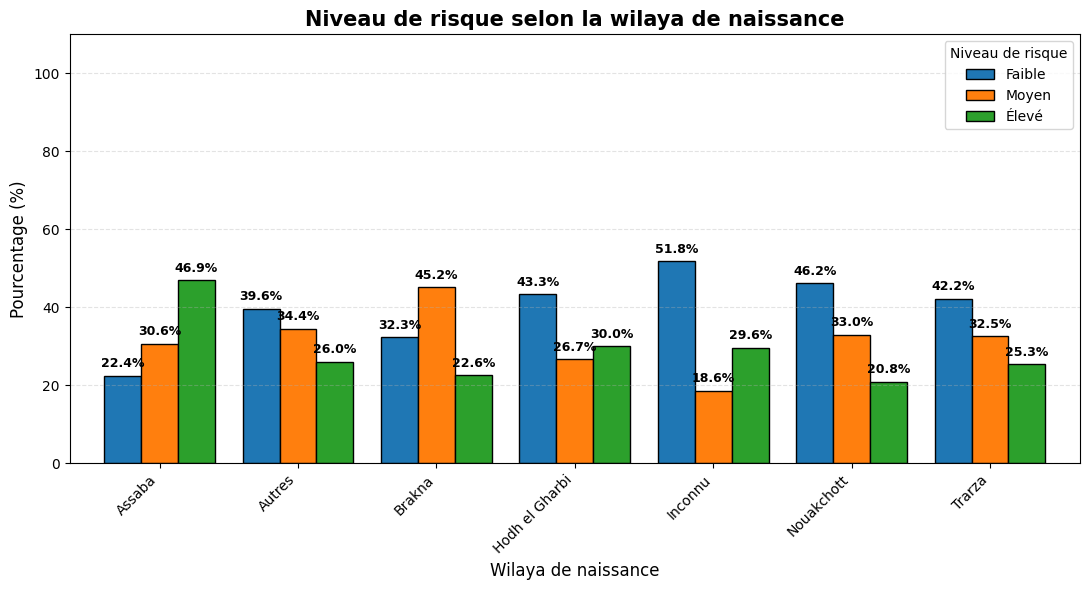

In [34]:
ax = tableau_wilaya.plot(
    kind="bar",
    figsize=(11, 6),
    width=0.8,
    edgecolor="black"
)

plt.title("Niveau de risque selon la wilaya de naissance", fontsize=15, fontweight="bold")
plt.xlabel("Wilaya de naissance", fontsize=12)
plt.ylabel("Pourcentage (%)", fontsize=12)

plt.xticks(rotation=45, ha="right")
plt.legend(title="Niveau de risque")
plt.grid(axis="y", linestyle="--", alpha=0.35)

# Ajouter les pourcentages sur les barres
for container in ax.containers:
    labels = [
        f"{value:.1f}%" if value > 0 else ""
        for value in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        fontsize=9,
        fontweight="bold",
        padding=4
    )

plt.ylim(0, 110)
plt.tight_layout()
plt.show()

In [35]:
tableau_effectifs_wilaya = pd.crosstab(
    df["WILAYA_NAISSANCE_GROUPE"],
    df["NIVEAU_RISQUE"]
)

display(tableau_effectifs_wilaya)

chi2, p_value, dof, expected = chi2_contingency(tableau_effectifs_wilaya)

print("Statistique Khi-deux :", chi2)
print("p-value :", p_value)
print("Degrés de liberté :", dof)

if p_value < 0.05:
    print("Il existe une relation statistiquement significative entre la wilaya de naissance et le niveau de risque.")
else:
    print("Il n'existe pas de relation statistiquement significative entre la wilaya de naissance et le niveau de risque.")

NIVEAU_RISQUE,Faible,Moyen,Élevé
WILAYA_NAISSANCE_GROUPE,,,
Assaba,11,15,23
Autres,61,53,40
Brakna,10,14,7
Hodh el Gharbi,13,8,9
Inconnu,187,67,107
Nouakchott,91,65,41
Trarza,35,27,21


Statistique Khi-deux : 42.54186723361285
p-value : 2.698869878580695e-05
Degrés de liberté : 12
Il existe une relation statistiquement significative entre la wilaya de naissance et le niveau de risque.


### NIVEAU_RISQUE x SECT_ACTIV

In [30]:
ordre = ["Faible", "Moyen", "Élevé"]

# Tableau croisé en pourcentage
tableau_sect = pd.crosstab(
    df["SECT_ACTIV_GROUPE"],
    df["NIVEAU_RISQUE"],
    normalize="index"
).mul(100).round(2)

tableau_sect = tableau_sect[ordre]

display(tableau_sect)

NIVEAU_RISQUE,Faible,Moyen,Élevé
SECT_ACTIV_GROUPE,,,
AUTRES,60.00,10.00,30.00
AUTRES SOCIETES,43.90,21.95,34.15
ENTREPRISES INDIVIDUELLES,45.02,28.29,26.69


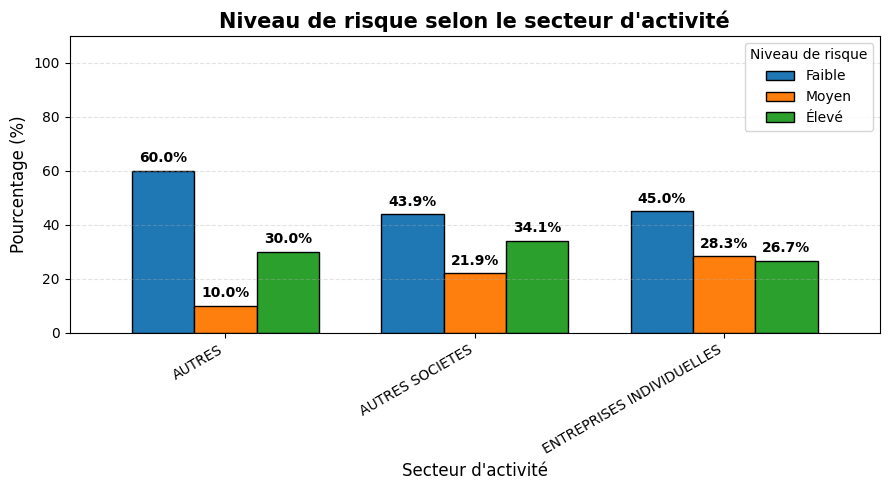

In [36]:
ax = tableau_sect.plot(
    kind="bar",
    figsize=(9, 5),
    width=0.75,
    edgecolor="black"
)

plt.title("Niveau de risque selon le secteur d'activité", fontsize=15, fontweight="bold")
plt.xlabel("Secteur d'activité", fontsize=12)
plt.ylabel("Pourcentage (%)", fontsize=12)

plt.xticks(rotation=30, ha="right")
plt.legend(title="Niveau de risque")
plt.grid(axis="y", linestyle="--", alpha=0.35)

# Ajouter les pourcentages sur les barres
for container in ax.containers:
    labels = [
        f"{value:.1f}%" if value > 0 else ""
        for value in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        fontsize=10,
        fontweight="bold",
        padding=4
    )

plt.ylim(0, 110)
plt.tight_layout()
plt.show()

In [37]:
# Tableau croisé en effectifs
tableau_effectifs_sect = pd.crosstab(
    df["SECT_ACTIV_GROUPE"],
    df["NIVEAU_RISQUE"]
)

display(tableau_effectifs_sect)

# Test du Khi-deux
chi2, p_value, dof, expected = chi2_contingency(tableau_effectifs_sect)

print("Statistique Khi-deux :", chi2)
print("p-value :", p_value)
print("Degrés de liberté :", dof)

if p_value < 0.05:
    print("Il existe une relation statistiquement significative entre le secteur d'activité et le niveau de risque.")
else:
    print("Il n'existe pas de relation statistiquement significative entre le secteur d'activité et le niveau de risque.")

NIVEAU_RISQUE,Faible,Moyen,Élevé
SECT_ACTIV_GROUPE,,,
AUTRES,6,1,3
AUTRES SOCIETES,36,18,28
ENTREPRISES INDIVIDUELLES,366,230,217


Statistique Khi-deux : 4.270439797271364
p-value : 0.3706412801811009
Degrés de liberté : 4
Il n'existe pas de relation statistiquement significative entre le secteur d'activité et le niveau de risque.


## Variables Quantitatives

### NIVEAU_RISQUE x MONTANT

In [40]:
df.groupby("NIVEAU_RISQUE")["MONTANT"].agg(
    Effectif="count",
    Moyenne="mean",
    Médiane="median",
    Minimum="min",
    Maximum="max",
    Ecart_type="std"
).round(2)

,Effectif,Moyenne,Médiane,Minimum,Maximum,Ecart_type
NIVEAU_RISQUE,,,,,,
Faible,408,2375415.74,1100000.0,100000.0,23779970.87,3267500.80
Moyen,249,2260723.43,1100000.0,150000.0,19176421.58,2673545.00
Élevé,248,2238539.82,1000000.0,160000.0,41018068.50,4154335.55


C:\Users\delli7\AppData\Local\Temp\ipykernel_2652\2869201662.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


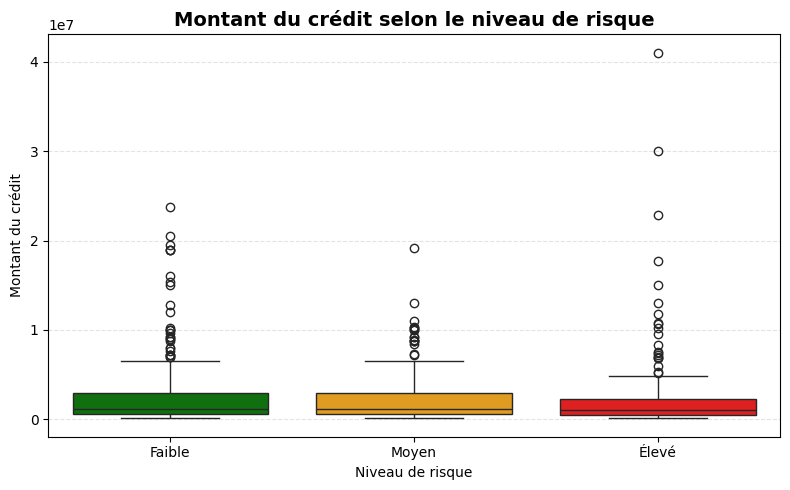

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

ordre = ["Faible", "Moyen", "Élevé"]

couleurs = {
    "Faible": "green",
    "Moyen": "orange",
    "Élevé": "red"
}

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="NIVEAU_RISQUE",
    y="MONTANT",
    order=ordre,
    palette=couleurs
)

plt.title("Montant du crédit selon le niveau de risque", fontsize=14, fontweight="bold")
plt.xlabel("Niveau de risque")
plt.ylabel("Montant du crédit")
plt.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

In [47]:
faible = df.loc[df["NIVEAU_RISQUE"] == "Faible", "MONTANT"]
moyen = df.loc[df["NIVEAU_RISQUE"] == "Moyen", "MONTANT"]
eleve = df.loc[df["NIVEAU_RISQUE"] == "Élevé", "MONTANT"]

stat, p_value = kruskal(faible, moyen, eleve)

print("Statistique Kruskal-Wallis :", stat)
print("p-value :", p_value)

if p_value < 0.05:
    print("Il existe une différence statistiquement significative du montant selon le niveau de risque.")
else:
    print("Il n'existe pas de différence statistiquement significative du montant selon le niveau de risque.")

Statistique Kruskal-Wallis : 5.531547404798422
p-value : 0.06292739343322779
Il n'existe pas de différence statistiquement significative du montant selon le niveau de risque.


### NIVEAU_RISQUE x DUREE

In [48]:
df.groupby("NIVEAU_RISQUE")["DUREE"].agg(
    Effectif="count",
    Moyenne="mean",
    Médiane="median",
    Minimum="min",
    Maximum="max",
    Ecart_type="std"
).round(2)

,Effectif,Moyenne,Médiane,Minimum,Maximum,Ecart_type
NIVEAU_RISQUE,,,,,,
Faible,408,51.35,48.0,8,144,10.59
Moyen,249,51.04,48.0,22,84,7.37
Élevé,248,50.74,48.0,24,96,9.23


C:\Users\delli7\AppData\Local\Temp\ipykernel_2652\3877209556.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


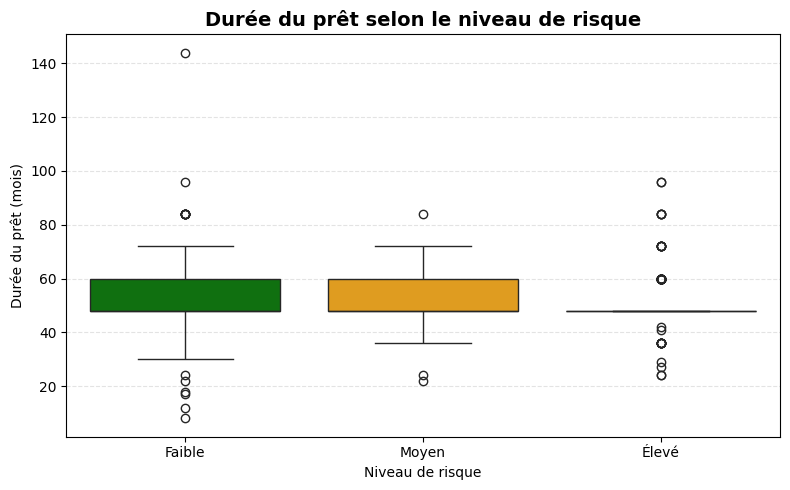

In [ ]:
ordre = ["Faible", "Moyen", "Élevé"]

couleurs = {
    "Faible": "green",
    "Moyen": "orange",
    "Élevé": "red"
}

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="NIVEAU_RISQUE",
    y="DUREE",
    order=ordre,
    palette=couleurs
)

plt.title("Durée du prêt selon le niveau de risque", fontsize=14, fontweight="bold")
plt.xlabel("Niveau de risque")
plt.ylabel("Durée du prêt (mois)")
plt.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

In [51]:
faible = df.loc[df["NIVEAU_RISQUE"] == "Faible", "DUREE"]
moyen = df.loc[df["NIVEAU_RISQUE"] == "Moyen", "DUREE"]
eleve = df.loc[df["NIVEAU_RISQUE"] == "Élevé", "DUREE"]

stat, p_value = kruskal(faible, moyen, eleve)

print("Statistique Kruskal-Wallis :", stat)
print("p-value :", p_value)

if p_value < 0.05:
    print("Il existe une différence statistiquement significative de la durée du prêt selon le niveau de risque.")
else:
    print("Il n'existe pas de différence statistiquement significative de la durée du prêt selon le niveau de risque.")

Statistique Kruskal-Wallis : 2.6450394875301457
p-value : 0.26646303677798916
Il n'existe pas de différence statistiquement significative de la durée du prêt selon le niveau de risque.


### NIVEAU_RISQUE x TAUX_INT

In [52]:
df.groupby("NIVEAU_RISQUE")["TAUX_INT"].agg(
    Effectif="count",
    Moyenne="mean",
    Médiane="median",
    Minimum="min",
    Maximum="max",
    Ecart_type="std"
).round(2)

,Effectif,Moyenne,Médiane,Minimum,Maximum,Ecart_type
NIVEAU_RISQUE,,,,,,
Faible,408,9.29,10.0,0.0,10.0,1.94
Moyen,249,9.23,10.0,0.0,10.0,2.26
Élevé,248,9.19,10.0,0.0,10.0,2.35


C:\Users\delli7\AppData\Local\Temp\ipykernel_2652\2009331003.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


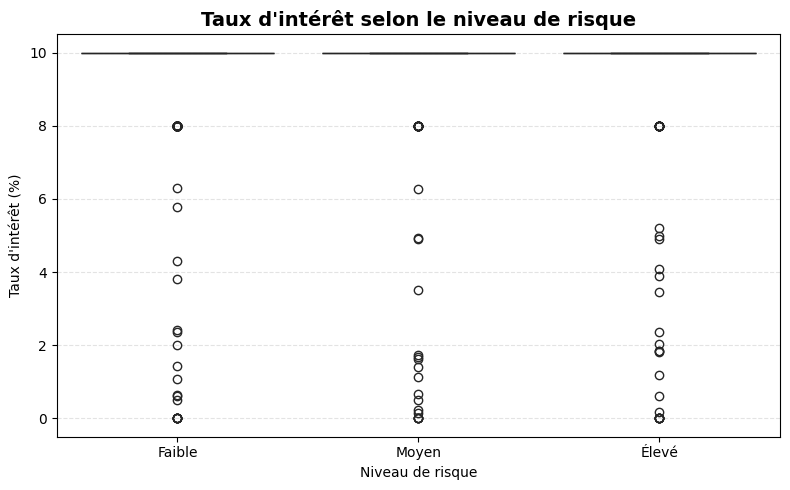

In [57]:
ordre = ["Faible", "Moyen", "Élevé"]

couleurs = {
    "Faible": "green",
    "Moyen": "orange",
    "Élevé": "red"
}

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="NIVEAU_RISQUE",
    y="TAUX_INT",
    order=ordre,
    palette=couleurs
)

plt.title("Taux d'intérêt selon le niveau de risque", fontsize=14, fontweight="bold")
plt.xlabel("Niveau de risque")
plt.ylabel("Taux d'intérêt (%)")
plt.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

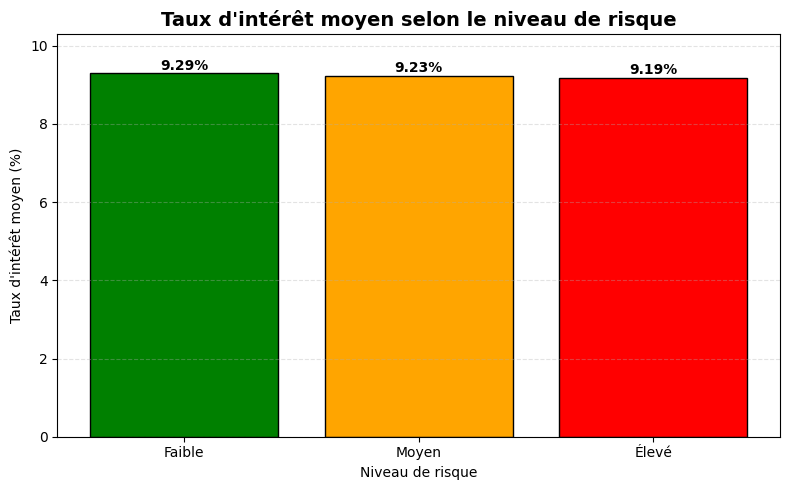

In [59]:
ordre = ["Faible", "Moyen", "Élevé"]

moyennes = df.groupby("NIVEAU_RISQUE")["TAUX_INT"].mean().reindex(ordre)

couleurs = ["green", "orange", "red"]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    moyennes.index,
    moyennes.values,
    color=couleurs,
    edgecolor="black"
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.1,
        f"{height:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.title("Taux d'intérêt moyen selon le niveau de risque", fontsize=14, fontweight="bold")
plt.xlabel("Niveau de risque")
plt.ylabel("Taux d'intérêt moyen (%)")
plt.ylim(0, moyennes.max() + 1)
plt.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

In [60]:
faible = df.loc[df["NIVEAU_RISQUE"] == "Faible", "TAUX_INT"]
moyen = df.loc[df["NIVEAU_RISQUE"] == "Moyen", "TAUX_INT"]
eleve = df.loc[df["NIVEAU_RISQUE"] == "Élevé", "TAUX_INT"]

stat, p_value = kruskal(faible, moyen, eleve)

print("Statistique Kruskal-Wallis :", stat)
print("p-value :", p_value)

if p_value < 0.05:
    print("Il existe une différence statistiquement significative du taux d'intérêt selon le niveau de risque.")
else:
    print("Il n'existe pas de différence statistiquement significative du taux d'intérêt selon le niveau de risque.")

Statistique Kruskal-Wallis : 2.459281149592476
p-value : 0.2923976538825367
Il n'existe pas de différence statistiquement significative du taux d'intérêt selon le niveau de risque.


### NIVEAU_RISQUE x NB_ECH

In [61]:
df.groupby("NIVEAU_RISQUE")["NB_ECH"].agg(
    Effectif="count",
    Moyenne="mean",
    Médiane="median",
    Minimum="min",
    Maximum="max",
    Ecart_type="std"
).round(2)

,Effectif,Moyenne,Médiane,Minimum,Maximum,Ecart_type
NIVEAU_RISQUE,,,,,,
Faible,408,40.24,48.0,4,84,12.95
Moyen,249,40.98,48.0,12,82,11.80
Élevé,248,42.54,48.0,4,96,11.75


C:\Users\delli7\AppData\Local\Temp\ipykernel_2652\110906037.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


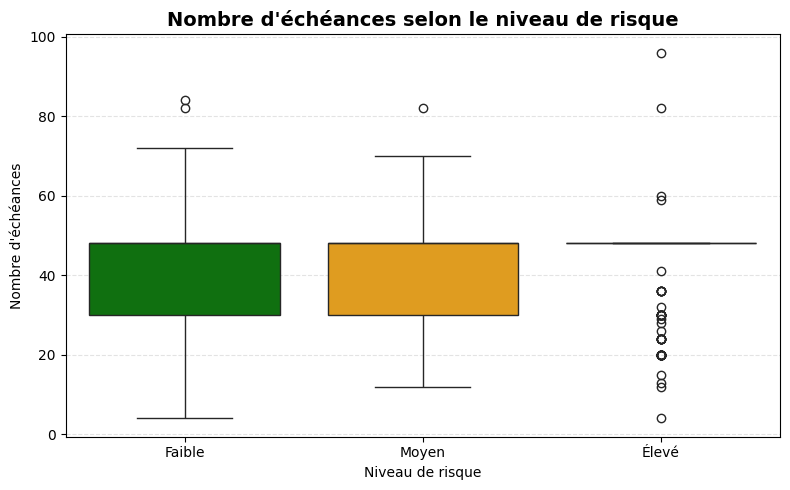

In [63]:
ordre = ["Faible", "Moyen", "Élevé"]

couleurs = {
    "Faible": "green",
    "Moyen": "orange",
    "Élevé": "red"
}

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="NIVEAU_RISQUE",
    y="NB_ECH",
    order=ordre,
    palette=couleurs
)

plt.title("Nombre d'échéances selon le niveau de risque", fontsize=14, fontweight="bold")
plt.xlabel("Niveau de risque")
plt.ylabel("Nombre d'échéances")
plt.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

In [64]:
faible = df.loc[df["NIVEAU_RISQUE"] == "Faible", "NB_ECH"]
moyen = df.loc[df["NIVEAU_RISQUE"] == "Moyen", "NB_ECH"]
eleve = df.loc[df["NIVEAU_RISQUE"] == "Élevé", "NB_ECH"]

stat, p_value = kruskal(faible, moyen, eleve)

print("Statistique Kruskal-Wallis :", stat)
print("p-value :", p_value)

if p_value < 0.05:
    print("Il existe une différence statistiquement significative du nombre d'échéances selon le niveau de risque.")
else:
    print("Il n'existe pas de différence statistiquement significative du nombre d'échéances selon le niveau de risque.")

Statistique Kruskal-Wallis : 5.585301014768823
p-value : 0.0612586320913017
Il n'existe pas de différence statistiquement significative du nombre d'échéances selon le niveau de risque.


### NIVEAU_RISQUE x VALEURGARANT

In [65]:
df.groupby("NIVEAU_RISQUE")["VALEURGARANT"].agg(
    Effectif="count",
    Moyenne="mean",
    Médiane="median",
    Minimum="min",
    Maximum="max",
    Ecart_type="std"
).round(2)

,Effectif,Moyenne,Médiane,Minimum,Maximum,Ecart_type
NIVEAU_RISQUE,,,,,,
Faible,408,6415342.24,3073500.0,100000,75808020,9641940.00
Moyen,249,5027951.74,2940000.0,296000,75808020,6625822.65
Élevé,248,3867224.74,1758125.0,141000,40000000,5375176.08


C:\Users\delli7\AppData\Local\Temp\ipykernel_2652\1653975806.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


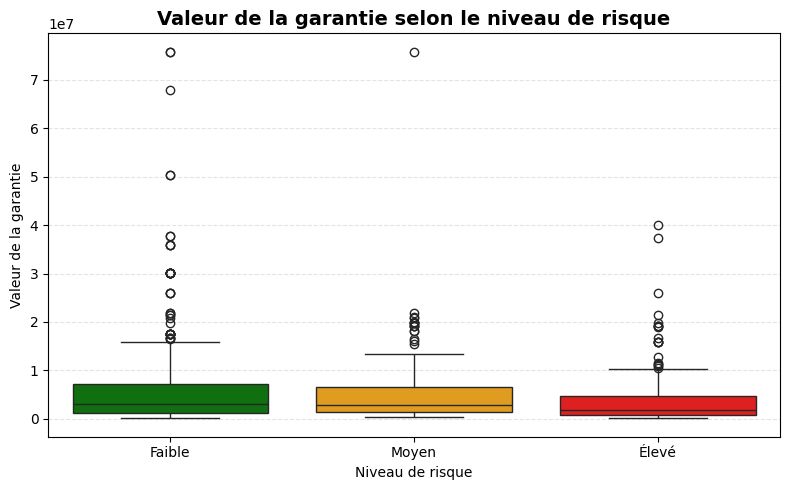

In [67]:
ordre = ["Faible", "Moyen", "Élevé"]

couleurs = {
    "Faible": "green",
    "Moyen": "orange",
    "Élevé": "red"
}

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="NIVEAU_RISQUE",
    y="VALEURGARANT",
    order=ordre,
    palette=couleurs
)

plt.title("Valeur de la garantie selon le niveau de risque", fontsize=14, fontweight="bold")
plt.xlabel("Niveau de risque")
plt.ylabel("Valeur de la garantie")
plt.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

In [68]:
faible = df.loc[df["NIVEAU_RISQUE"] == "Faible", "VALEURGARANT"]
moyen = df.loc[df["NIVEAU_RISQUE"] == "Moyen", "VALEURGARANT"]
eleve = df.loc[df["NIVEAU_RISQUE"] == "Élevé", "VALEURGARANT"]

stat, p_value = kruskal(faible, moyen, eleve)

print("Statistique Kruskal-Wallis :", stat)
print("p-value :", p_value)

if p_value < 0.05:
    print("Il existe une différence statistiquement significative de la valeur de la garantie selon le niveau de risque.")
else:
    print("Il n'existe pas de différence statistiquement significative de la valeur de la garantie selon le niveau de risque.")

Statistique Kruskal-Wallis : 23.292935516995566
p-value : 8.749904617618346e-06
Il existe une différence statistiquement significative de la valeur de la garantie selon le niveau de risque.


### NIVEAU_RISQUE x AGE

In [69]:
df.groupby("NIVEAU_RISQUE")["AGE"].agg(
    Effectif="count",
    Moyenne="mean",
    Médiane="median",
    Minimum="min",
    Maximum="max",
    Ecart_type="std"
).round(2)

,Effectif,Moyenne,Médiane,Minimum,Maximum,Ecart_type
NIVEAU_RISQUE,,,,,,
Faible,408,54.95,56.0,23,85,11.10
Moyen,249,51.22,52.0,28,77,10.71
Élevé,248,53.54,53.0,26,80,11.00


C:\Users\delli7\AppData\Local\Temp\ipykernel_2652\4021540090.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


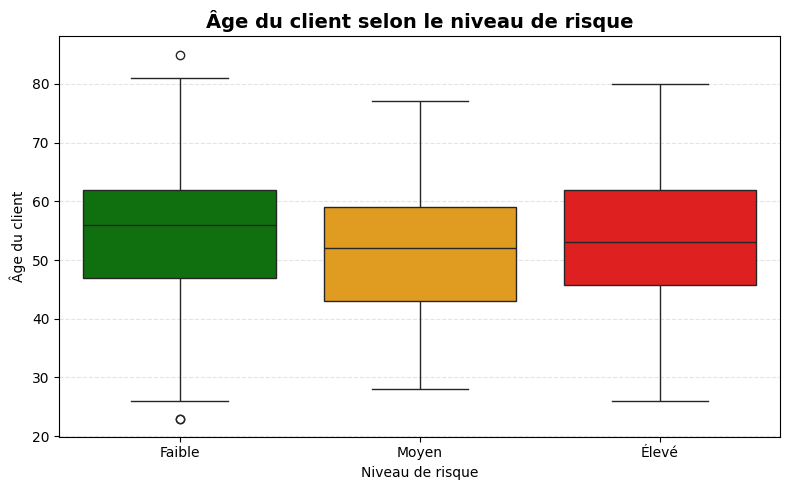

In [70]:
ordre = ["Faible", "Moyen", "Élevé"]

couleurs = {
    "Faible": "green",
    "Moyen": "orange",
    "Élevé": "red"
}

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="NIVEAU_RISQUE",
    y="AGE",
    order=ordre,
    palette=couleurs
)

plt.title("Âge du client selon le niveau de risque", fontsize=14, fontweight="bold")
plt.xlabel("Niveau de risque")
plt.ylabel("Âge du client")
plt.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

In [71]:
faible = df.loc[df["NIVEAU_RISQUE"] == "Faible", "AGE"]
moyen = df.loc[df["NIVEAU_RISQUE"] == "Moyen", "AGE"]
eleve = df.loc[df["NIVEAU_RISQUE"] == "Élevé", "AGE"]

stat, p_value = kruskal(faible, moyen, eleve)

print("Statistique Kruskal-Wallis :", stat)
print("p-value :", p_value)

if p_value < 0.05:
    print("Il existe une différence statistiquement significative de l'âge selon le niveau de risque.")
else:
    print("Il n'existe pas de différence statistiquement significative de l'âge selon le niveau de risque.")

Statistique Kruskal-Wallis : 17.29367164361072
p-value : 0.00017568185832436434
Il existe une différence statistiquement significative de l'âge selon le niveau de risque.


# Clustering

In [72]:
# Les variables de clustering
variables_cluster = [
    "MONTANT",
    "DUREE",
    "TAUX_INT",
    "NB_ECH",
    "VALEURGARANT",
    "AGE"
]

In [73]:
# Preparer les donner pour le clustering
from sklearn.preprocessing import StandardScaler

X = df[variables_cluster].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

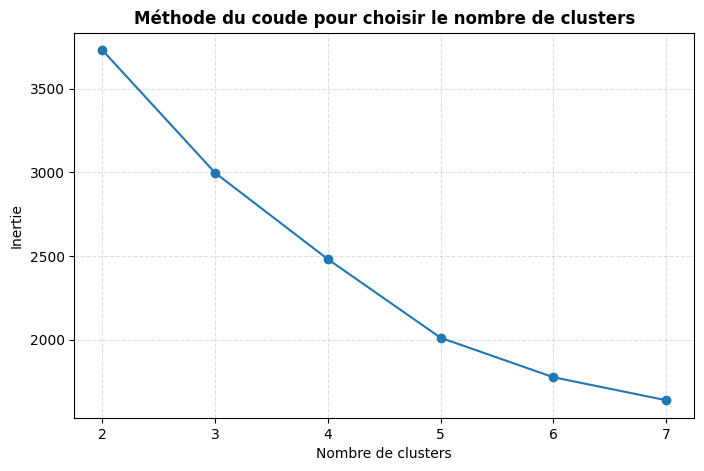

In [74]:
# Trouver le meuiler numéro de clusters
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 8), inertias, marker="o")
plt.title("Méthode du coude pour choisir le nombre de clusters", fontweight="bold")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

In [75]:
# Appliquer le K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df["CLUSTER"] = kmeans.fit_predict(X_scaled)

In [76]:
df.groupby("CLUSTER")[variables_cluster].mean().round(2)

,MONTANT,DUREE,TAUX_INT,NB_ECH,VALEURGARANT,AGE
CLUSTER,,,,,,
0,1072640.65,47.63,9.77,47.63,2465806.06,52.84
1,5739477.51,62.53,9.55,24.21,13570544.87,54.42
2,2588705.12,43.94,1.31,33.44,4877408.30,58.42


In [77]:
df["CLUSTER"].value_counts()

CLUSTER
0    632
1    223
2     50
Name: count, dtype: int64

In [78]:
# Comparer les clusters avec le niveau du risque. 
pd.crosstab(
    df["CLUSTER"],
    df["NIVEAU_RISQUE"],
    normalize="index"
).mul(100).round(2)

NIVEAU_RISQUE,Faible,Moyen,Élevé
CLUSTER,,,
0,43.83,26.74,29.43
1,51.12,28.70,20.18
2,34.00,32.00,34.00
